# 04 - KPI validation and SLA sensitivity

**Business questions:** Which KPIs can be trusted, and how? How sensitive are the conclusions to the SLA
definition (P70/P75/P80/P90)? What are the illustrative what-if scenarios, and what can't be quantified?


In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "routeiq").exists())
sys.path.insert(0, str(ROOT / "src"))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40); pd.set_option("display.max_colwidth", 110)
from routeiq.analysis import figures
figures.apply_theme()
from routeiq.config import FIGURES_DIR, TABLES_DIR, CLEANED_DELIVERY_CSV, RAW_DATA_CSV
from routeiq.features.analytical import load_analytical_dataset
df = load_analytical_dataset()
tbl = lambda name: pd.read_csv(TABLES_DIR / f"{name}.csv")
show = lambda name: display(Image(filename=str(FIGURES_DIR / name)))
say = lambda s: display(Markdown(s))
print(f"{len(df):,} deliveries loaded from the controlled analytical dataset")


43,648 deliveries loaded from the controlled analytical dataset


## 1. Statistical test register
Every test states the business question, why it was chosen, the practical meaning and its limitation.


In [2]:
reg = tbl("statistical_test_register")
display(reg[["id", "business_question", "effect_size_name", "effect_size", "effect_band", "headline_contrast", "p_value"]])


,id,business_question,effect_size_name,effect_size,effect_band,headline_contrast,p_value
0,T1,Is breach rate related to traffic level?,Cramer's V,0.348,medium,Jam vs Low (risk ratio),0.000
1,T2,Is breach rate related to weather?,Cramer's V,0.233,small,Cloudy/Fog vs Sunny,0.000
2,T3,Is breach rate related to area type?,Cramer's V,0.165,small,Metropolitian vs Urban,0.000
3,T4,Is breach rate related to vehicle type?,Cramer's V,0.113,small,Motorcycle vs scooter/van,0.000
4,T5,Is breach rate related to time of day?,Cramer's V,0.351,medium,Peak (17-23h) vs off-peak,0.000
5,T6,Is breach rate related to agent rating?,Cramer's V,0.458,medium,rating < 4.5 vs >= 4.5,0.000
6,T7,Is breach rate related to agent age?,Cramer's V,0.223,small,age >= 30 vs < 30,0.000
7,T8,Is breach rate related to weekend vs weekday?,Cramer's V,0.001,negligible,Weekend vs weekday,0.872
8,T9,Is breach rate related to preparation time?,Cramer's V,0.006,negligible,15 vs 5 minutes,0.409
9,T10,Does delivery time differ across traffic levels?,epsilon-squared,0.140,large,medians by traffic,0.000


In [3]:
for r in reg.itertuples():
    say(f"**{r.id} - {r.business_question}**  \nWhy this method: {r.why_this_test}  \nMeaning: {r.practical_meaning}  \nLimitation: {r.limitations}")


**T1 - Is breach rate related to traffic level?**  
Why this method: Breach is binary and the factor is categorical; V is comparable across factors of different size.  
Meaning: Breach rate is several times higher in Jam than Low traffic.  
Limitation: Traffic is almost a function of order hour (Jam only 19-22h); effects of traffic and time of day overlap.

**T2 - Is breach rate related to weather?**  
Why this method: Breach is binary and the factor is categorical; V is comparable across factors of different size.  
Meaning: Cloudy and Fog carry clearly higher breach rates than Sunny.  
Limitation: The traffic effect depends on weather (interaction), so this main effect is an average.

**T3 - Is breach rate related to area type?**  
Why this method: Breach is binary and the factor is categorical; V is comparable across factors of different size.  
Meaning: Metropolitian breaches more often than Urban.  
Limitation: Semi-Urban (n=152, 100% breach) is included in V but excluded from the contrast; area is confounded with traffic and agent mix.

**T4 - Is breach rate related to vehicle type?**  
Why this method: Breach is binary and the factor is categorical; V is comparable across factors of different size.  
Meaning: Motorcycle deliveries breach noticeably more often.  
Limitation: Vehicle assignment is not randomised; other differences may travel with vehicle type.

**T5 - Is breach rate related to time of day?**  
Why this method: Breach is binary and the factor is categorical; V is comparable across factors of different size.  
Meaning: Breaches concentrate in the evening peak, especially 19-21h.  
Limitation: Hour bands were chosen after inspecting the data; peak rule (>=2x median hourly volume) is descriptive.

...

**T10 - Does delivery time differ across traffic levels?**  
Why this method: Delivery time is skewed and group variances differ (Levene), so a rank-based test is safer than ANOVA.  
Meaning: Share of rank variance in delivery time associated with traffic.  
Limitation: Omnibus test only; no post-hoc method was pre-specified. Not comparable to r-squared.

**T11 - Does delivery time differ across weather levels?**  
Why this method: Delivery time is skewed and group variances differ (Levene), so a rank-based test is safer than ANOVA.  
Meaning: Share of rank variance in delivery time associated with weather.  
Limitation: Omnibus test only; no post-hoc method was pre-specified. Not comparable to r-squared.

**T12 - Is delivery time different on weekends?**  
Why this method: Rank-based test for skewed times; effect sizes tell the practical story.  
Meaning: Practically identical; a clean null result.  
Limitation: About 8 weeks of data.

**T13 - Do low-rated deliveries take longer?**  
Why this method: Rank-based test for skewed times; effect sizes tell the practical story.  
Meaning: Low-rated deliveries take about 50 minutes longer on average, a large effect.  
Limitation: Reverse causation is plausible (slow deliveries may earn low ratings).

**T14 - Do deliveries by agents aged 30+ take longer?**  
Why this method: Rank-based test for skewed times; effect sizes tell the practical story.  
Meaning: A sizeable step at age 30.  
Limitation: Data-driven cut; area and rating mix differ by age group.

**On p-values:** with about 43,000 deliveries, almost every comparison reaches statistical significance, so no
conclusion in this project rests on a p-value alone. What is reported and interpreted is the **effect size**
(percentage-point difference, risk ratio, Cramer's V, epsilon-squared) with its confidence interval.


## 2. Cross-layer KPI reconciliation
The same KPIs computed independently four ways: plain Python (standard library, no pandas), the pandas analysis pipeline, PostgreSQL, and what the v1 Power BI report displayed.


In [4]:
rec = tbl("reconciliation")
say(f"**{(rec.status == 'PASS').sum()} of {len(rec)} metrics agree** across every layer that can supply a value.")
display(rec[rec.status != "PASS"])
say("The one known exception is a Pareto label in the v1 Power BI report, caused by tie-handling in its ranking measure - documented, not silently different.")


**121 of 122 metrics agree** across every layer that can supply a value.

,metric,independent_csv,pandas_outputs,sql,powerbi_v1_displayed,status,notes
115,pareto_cumulative_pct_rank_7,96.001,96.001,NaN,97.000,PBI_v1_DIFFERS,v1 Power BI display differs from the reconciled value


The one known exception is a Pareto label in the v1 Power BI report, caused by tie-handling in its ranking measure - documented, not silently different.

**What this reconciliation shows, and does not show.** Agreement across independently written code paths reading
the same file rules out an implementation bug in any one layer. It is not proof that the underlying data is
correct - see notebook 01 for the data-realism findings.


## 3. SLA sensitivity: P70 / P75 / P80 / P90

**The SLA threshold is an analyst-defined benchmark** (each category's own P75 of delivery time), not a
company-published target. About a quarter of deliveries breach *by construction* at P75. This section checks
which findings survive a different threshold.


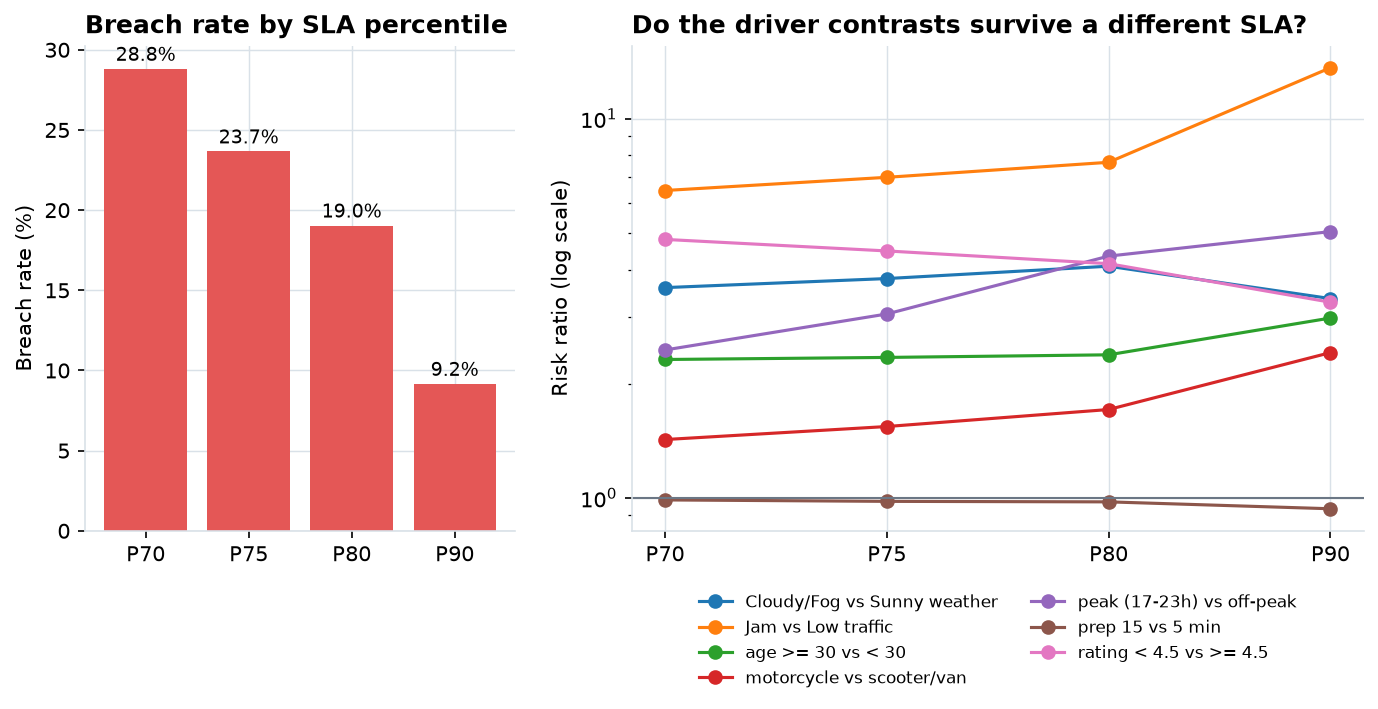

,percentile,breached_deliveries,breach_rate_pct,on_time_rate_pct,expected_breach_rate_if_no_ties_pct
0,0.700,12577,28.815,71.185,30.000
1,0.750,10328,23.662,76.338,25.000
2,0.800,8310,19.039,80.961,20.000
3,0.900,4000,9.164,90.836,10.000


In [5]:
show("sla_sensitivity.png")
ov = tbl("sla_sensitivity_overall")
display(ov)


In [6]:
rk = tbl("sla_sensitivity_ranking_stability")
display(rk[rk.percentile != 0.75][["variable", "percentile", "n_levels", "kendall_tau_vs_p75", "same_highest_level_as_p75", "same_lowest_level_as_p75"]])
say("**The riskiest level never changes** at any threshold (Jam traffic, Fog weather, the evening peak, age >= 30, rating < 4.5, motorcycle). "
    "The ordering of the middle levels shifts a little (Kendall tau 0.67-1.00). Levels with fewer than 200 deliveries (e.g. Semi-Urban) are excluded from rank comparisons - too few to rank reliably.")


,variable,percentile,n_levels,kendall_tau_vs_p75,same_highest_level_as_p75,same_lowest_level_as_p75
0,age_group,0.700,2,NaN,True,True
2,age_group,0.800,2,NaN,True,True
3,age_group,0.900,2,NaN,True,True
4,area,0.700,3,1.000,True,True
6,area,0.800,3,1.000,True,True
7,area,0.900,3,1.000,True,True
8,hour_band,0.700,7,0.905,True,True
10,hour_band,0.800,7,0.905,True,True
11,hour_band,0.900,7,0.905,True,True
12,rating_group,0.700,2,NaN,True,True


**The riskiest level never changes** at any threshold (Jam traffic, Fog weather, the evening peak, age >= 30, rating < 4.5, motorcycle). The ordering of the middle levels shifts a little (Kendall tau 0.67-1.00). Levels with fewer than 200 deliveries (e.g. Semi-Urban) are excluded from rank comparisons - too few to rank reliably.

In [7]:
drv = tbl("sla_sensitivity_driver_risk_ratios")
display(drv.pivot(index="contrast", columns="percentile", values="risk_ratio"))
say("**Direction is stable, magnitude is not.** Risk ratios for rating and traffic shrink or grow several-fold across thresholds, so a specific risk-ratio number should always be quoted together with the SLA percentile it was computed at.")
display(tbl("sla_sensitivity_semi_urban"))


percentile,0.700,0.750,0.800,0.900
contrast,,,,
Cloudy/Fog vs Sunny weather,3.585,3.787,4.082,3.354
Jam vs Low traffic,6.464,7.003,7.671,13.619
age >= 30 vs < 30,2.317,2.346,2.384,2.980
motorcycle vs scooter/van,1.425,1.542,1.710,2.416
peak (17-23h) vs off-peak,2.455,3.054,4.340,5.037
prep 15 vs 5 min,0.988,0.979,0.976,0.936
rating < 4.5 vs >= 4.5,4.803,4.479,4.146,3.281


**Direction is stable, magnitude is not.** Risk ratios for rating and traffic shrink or grow several-fold across thresholds, so a specific risk-ratio number should always be quoted together with the SLA percentile it was computed at.

,percentile,semi_urban_n,semi_urban_breach_rate
0,0.700,152,1.000
1,0.750,152,1.000
2,0.800,152,1.000
3,0.900,152,1.000


**What would we need to remove this dependency?** A real, externally-set SLA or customer-facing delivery-time
promise, so breach is measured against a business commitment instead of the dataset's own P75.


## 4. Illustrative scenarios

> **Illustrative scenario - not a causal forecast.** Each scenario asks only: "if this group's breach rate
> matched a comparison group's, holding today's volume and mix fixed, how many fewer breaches would that be?"
> No cost, revenue or capacity data exists in this dataset, so **no financial impact is estimated.**


,scenario,n_group,baseline_group_breach_rate,comparison_breach_rate,reduction_breaches,reduction_pct_of_all_breaches
0,Jam-traffic breach rate matches Medium-traffic rate,13725,0.426,0.246,"2,472.154",23.936
1,Rating < 4.5 breach rate matches rating >= 4.5 rate,8024,0.646,0.144,"4,027.306",38.994
2,Jam + Cloudy/Fog breach rate matches Jam + other adverse weather,4632,0.666,0.360,"1,416.803",13.718


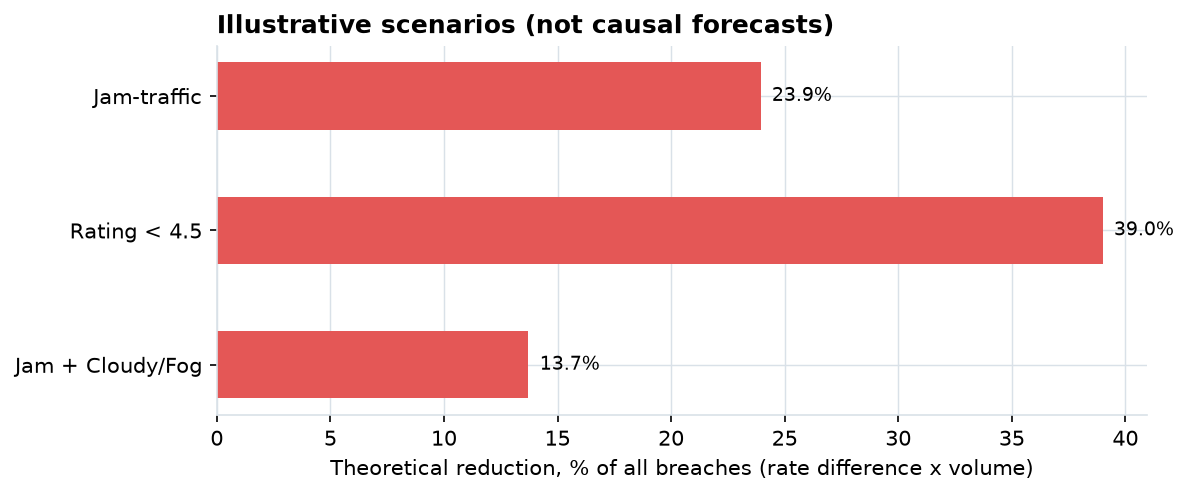

**Jam-traffic breach rate matches Medium-traffic rate.** Assumption: Every Jam-traffic delivery would breach at the rate today's Medium-traffic deliveries do, keeping the same volume and mix of everything else.  
Limitation: Jam occurs only 19:00-22:00 in this data, so 'traffic' cannot be separated from time of day. It is unknown what operational lever could move Jam-hour performance to Medium level.

**Rating < 4.5 breach rate matches rating >= 4.5 rate.** Assumption: Every low-rating delivery would breach at the rate today's higher-rating deliveries do.  
Limitation: Rating may be an OUTCOME of delivery performance (reverse causation) or a marker of route/shift assignment. This does not show that coaching or reassigning agents would change breaches.

**Jam + Cloudy/Fog breach rate matches Jam + other adverse weather.** Assumption: The highest-risk traffic-weather combination would breach at the rate of the next-highest adverse combination.  
Limitation: Weather is not controllable; this sizes the concentration of risk, not an action.

In [8]:
sc = tbl("scenarios")
display(sc[["scenario", "n_group", "baseline_group_breach_rate", "comparison_breach_rate", "reduction_breaches", "reduction_pct_of_all_breaches"]])
show("scenarios.png")
for r in sc.itertuples():
    say(f"**{r.scenario}.** Assumption: {r.assumption}  \nLimitation: {r.limitation}")


### What would we need from the business before recommending operational changes?
1. A real, customer-facing SLA or delivery-time promise (to replace the analyst-defined P75 benchmark).
2. An agent identifier and rating timestamps (to test whether rating reflects agent performance or delivery outcome).
3. Timestamps for dispatch, pickup and drop that are independent of the traffic label (to separate traffic from time of day).
4. Cost, capacity and staffing data (to size any recommended change).
5. Confirmation of how this dataset was generated, and whether the patterns found here (the rating/age steps, the
   traffic-hour overlap) reflect real operations or the data-generation process (notebook 01).
